# Améliorer une « mauvaise » distribution

![feature engineering](../../images/feature-engineering-process.png)

## Le problème : certains algorithmes préfèrent les gaussiennes

Beaucoup d'algorithmes de machine learning font des **hypothèses implicites sur la distribution** des variables d'entrée. La plus courante : *« les données sont à peu près gaussiennes »* — c'est-à-dire en forme de cloche, symétriques, centrées autour de leur moyenne avec une dispersion régulière.

**Les algorithmes qui aiment les données gaussiennes (ou au moins symétriques) :**
- **Régression linéaire / logistique** (surtout avec régularisation $L_1$ ou $L_2$).
- **KNN, K-Means** (tout ce qui utilise des distances euclidiennes).
- **SVM avec kernel linéaire ou RBF.**
- **Réseaux de neurones** (les activations convergent mieux si les entrées sont standardisées).
- **Analyses statistiques** (ANOVA, tests de Student, etc.).

**Les algorithmes qui s'en moquent :**
- **Arbres de décision, Random Forest, XGBoost, LightGBM.** Ils découpent par seuils, donc l'échelle et la forme de la distribution n'ont aucune importance pour eux.

### Pourquoi c'est gênant quand ça déraille

> **L'analogie à garder en tête :** imagine que tu compares deux amis avec deux balances différentes. Si ta balance A lit les valeurs en grammes (de 0 à 100 000) et la balance B en kilos (de 0 à 100), tu vas forcément **donner plus de poids** (pardon du jeu de mots) à la première dans ta comparaison. C'est exactement ce que fait un modèle linéaire avec des variables de distributions très différentes : `fare` (0 à 500) va dominer `pclass` (1 à 3) dans les calculs, **sans raison métier**.
>
> Et au-delà de l'échelle, **la forme** de la distribution compte aussi. Une variable très asymétrique peut avoir un effet non linéaire sur le modèle — un modèle linéaire passera à côté, tandis qu'une transformation simple (log, racine, puissance) peut lui redonner une forme exploitable.

![feature engineering](../../images/skew.png)

## Le plan de ce notebook

1. **Détecter** les distributions asymétriques (via le **skew**).
2. **Transformer** les variables problématiques avec log, racine ou puissance.
3. **Normaliser** l'ensemble des variables (scaling centré-réduit).
4. **Vérifier** si ça apporte un gain mesurable sur les modèles.

> **Spoiler :** ça ne marche **pas à tous les coups**. Le feature engineering, c'est de l'expérimentation — et ce notebook finira sur un résultat « rien de mieux », ce qui est une leçon tout aussi importante que les succès.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style('whitegrid')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [2]:
titanic = fetch_openml("titanic", version=1, as_frame=True)
titanic1 = titanic.data
survived = titanic.target.astype(np.int8)

## Création des jeux d'apprentissage et de test

**On utilise un split stratifié** (`stratify=y`) pour garantir que les deux jeux ont la même proportion de survivants — critique quand les classes sont déséquilibrées, comme vu dans le notebook précédent.

In [3]:
X1_train, X1_test, y_train, y_test = train_test_split(
    titanic1,
    survived,
    test_size=0.25,
    stratify=survived,
    random_state=2
)

On vérifie à nouveau la distribution des labels pour confirmer que les deux jeux sont bien alignés.

## Feature selection — suppression des colonnes inutiles

**Conformément aux choix faits dans les notebooks précédents**, on supprime les colonnes problématiques : trop de NaN (`cabin`, `home.dest`), fuites de données (`boat`, `body`), haute cardinalité non exploitée (`name`, `ticket`).

In [4]:
def drop_columns(X_df):
    return X_df.drop(
        ["cabin", "home.dest", "boat", "body", "name", "ticket"], axis=1
    )

In [5]:
X2_train = drop_columns(X1_train)

## Data cleaning — valorisation des données manquantes

**Rappel rapide de la stratégie du notebook précédent :**
- `embarked` : imputé par le mode (`S`).
- `fare` : imputé par la moyenne conditionnée à `pclass`.
- `age` : imputé par un tirage aléatoire autour de la moyenne de sa classe.

### La colonne `embarked`

On remplace la valeur manquante par la valeur la plus fréquente — **`S`** (Southampton).

In [6]:
def impute_embarked(X_df):
    return X_df["embarked"].fillna("S")

assert impute_embarked(X2_train).notnull().all()

### La colonne `fare`

On valorise les valeurs manquantes de `fare` **en fonction de `pclass`** (imputation conditionnelle, cf. notebook précédent).

In [7]:
mean_fare_per_class = X2_train.groupby( "pclass")["fare"].mean()
mean_fare_per_class

pclass
1    82.752701
2    21.298985
3    13.410947
Name: fare, dtype: float64

In [8]:
def impute_fare(X_df):
    return X2_train.apply(
        lambda row: mean_fare_per_class[row["pclass"]] if np.isnan(row["fare"]) else row["fare"],
        axis=1
    )

assert impute_fare(X2_train).notnull().all()

### La colonne `age`

Nous allons valoriser les valeurs de `age` autour de l'**âge moyen de la classe** des voyageurs (imputation conditionnelle avec bruit pour préserver la distribution).

In [9]:
mean_ages_class = X2_train.groupby("pclass")["age"].mean()
std_ages_class = X2_train.groupby("pclass")["age"].std()
mean_ages_class, std_ages_class

(pclass
 1    39.778325
 2    29.574292
 3    24.637874
 Name: age, dtype: float64,
 pclass
 1    14.287973
 2    13.380506
 3    11.802561
 Name: age, dtype: float64)

In [10]:
def get_age(row, mean_ages, std_ages):
    pclass = row['pclass']
    mean_age = mean_ages[pclass]
    std_age = std_ages[pclass]
    return np.random.normal(loc=mean_age, scale=std_age/4)

def impute_age(X_df, mean_ages, std_ages):
    return X_df.apply(
        lambda row: get_age(
            row, mean_ages, std_ages
        ) if np.isnan(row["age"]) else row["age"],
        axis=1
    )
assert impute_age(X2_train, mean_ages_class, std_ages_class).notnull().all()
assert impute_age(X2_train, mean_ages_class, std_ages_class).iloc[0] == X2_train.iloc[0]["age"] 

**Vérification** : on compare les distributions **avant** et **après** imputation. On veut s'assurer que notre stratégie n'a pas créé d'artefact (pic démesuré à une valeur unique).

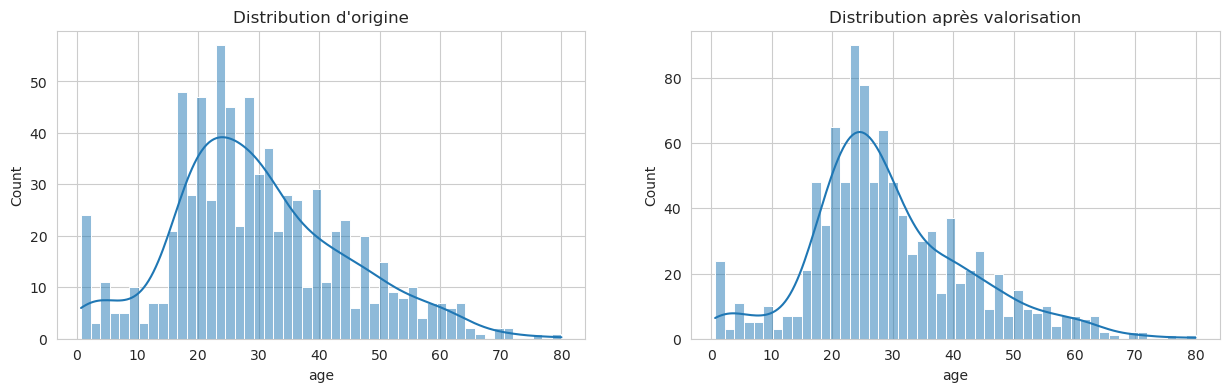

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(x=X2_train["age"], kde=True, bins=50, ax=ax1)
ax1.set_title("Distribution d'origine")
ax1.set_xlabel("age")
sns.histplot(x=impute_age(X2_train, mean_ages_class, std_ages_class), kde=True, bins=50, ax=ax2)
ax2.set_title("Distribution après valorisation")
ax2.set_xlabel("age");

**La valorisation n'a pas radicalement déformé la distribution** — c'est bon signe. L'imputation conditionnelle avec tirage aléatoire préserve mieux la forme naturelle que l'imputation par une constante.

### Valorisation — la fonction complète

On rassemble toutes les stratégies d'imputation dans une seule fonction réutilisable sur le train **et** le test.

In [12]:
def impute_null_values(X_df, mean_ages, std_ages):
    X_df["embarked"] = impute_embarked(X_df)
    X_df["fare"] = impute_fare(X_df)
    X_df["age"] = impute_age(X_df, mean_ages, std_ages)
    return X_df

impute_null_values(X2_train.copy(), mean_ages_class, std_ages_class)

,pclass,sex,age,sibsp,parch,fare,embarked
3,1,male,30.000000,1,2,151.5500,S
798,3,male,25.180123,0,0,7.0500,S
38,1,male,41.000000,0,0,30.5000,S
367,2,male,52.000000,0,0,13.5000,S
803,3,male,26.000000,0,0,7.8792,Q
...,...,...,...,...,...,...,...
727,3,male,70.500000,0,0,7.7500,Q
645,3,male,23.000000,0,0,7.7958,S
380,2,female,22.000000,0,0,10.5000,S
366,2,male,54.000000,1,0,26.0000,S


## Numérisation des variables catégorielles

**Dernière étape avant les transformations de distribution** : convertir `sex` et `embarked` en variables numériques via one-hot encoding (avec `drop_first=True` pour éviter la colinéarité).

In [13]:
def convert_categorical(X_df, cols):
    one_hot_encoded = pd.get_dummies(X_df[cols], drop_first=True)
    return X_df.join(one_hot_encoded).drop(cols, axis=1)

convert_categorical(X2_train.copy(), ["sex", "embarked"]).info()

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 3 to 1117
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      981 non-null    int64  
 1   age         771 non-null    float64
 2   sibsp       981 non-null    int64  
 3   parch       981 non-null    int64  
 4   fare        980 non-null    float64
 5   sex_male    981 non-null    bool   
 6   embarked_Q  981 non-null    bool   
 7   embarked_S  981 non-null    bool   
dtypes: bool(3), float64(2), int64(3)
memory usage: 81.1 KB


## Gestion d'une mauvaise distribution — les transformations

**C'est le cœur de ce notebook.** On va maintenant s'attaquer aux variables dont la distribution est **asymétrique** (*skewed*), et voir si une transformation mathématique simple peut la rendre plus symétrique.

### Les transformations classiques

Quand une variable a une **traîne à droite** (skew positif — cas très fréquent : prix, revenus, temps d'attente), on peut essayer :

| Transformation | Formule | Effet |
|---|---|---|
| **Log** | $y = \log(x + 1)$ | Compression forte des grandes valeurs. Classique pour les prix, revenus. |
| **Racine carrée** | $y = \sqrt{x}$ | Compression modérée. Bon compromis pour des variables peu asymétriques. |
| **Puissance** $p < 1$ | $y = x^p$ | Effet modulable en jouant sur $p$ ($p=0{,}5$ = racine, $p=0{,}3$ = plus fort). |
| **Box-Cox** | automatique | Trouve le meilleur $p$ automatiquement (variables strictement positives). |
| **Yeo-Johnson** | automatique | Comme Box-Cox mais accepte les valeurs négatives ou nulles. |

> **Mental model :** une traîne à droite, c'est comme un élastique qu'on a trop tiré d'un côté. Les transformations compressent les grandes valeurs et « ramènent » l'élastique vers une forme plus équilibrée. Plus la transformation est « forte » (log > racine > puissance 0,7), plus elle compresse.

### Pourquoi ça aide (parfois)

- **Les algorithmes linéaires** (régression, régression logistique) apprennent mieux sur des variables **symétriques** — ils peuvent mieux ajuster un coefficient unique qui s'applique de façon équilibrée.
- **Les tests statistiques** qui reposent sur l'hypothèse de normalité deviennent valides.
- **La régularisation** (Ridge, Lasso) traite mieux les variables d'échelles comparables.

### La variable `age`

L'histogramme (vu plus haut) révèle une **traîne à droite** de la variable `age`. On peut **quantifier** cette asymétrie avec la fonction **`skew()`** de pandas.

> **Rappel du notebook `01-intro-datascience/06-statistics-basics` :**
>
> - **skew = 0** → distribution symétrique (gaussienne parfaite).
> - **skew > 0** → traîne à droite (queue vers les grandes valeurs). **Plus la valeur est grande, plus l'asymétrie est forte.**
> - **skew < 0** → traîne à gauche (queue vers les petites valeurs).

In [14]:
age = impute_age(X2_train, mean_ages_class, std_ages_class)
age.skew()

np.float64(0.5740560204482913)

**Une valeur positive** confirme une traîne à droite (quelques voyageurs âgés tirent la distribution vers la droite). Pour corriger cela, on va essayer plusieurs transformations et comparer visuellement — **log**, **racine carrée**, **puissance 0,7** — puis choisir celle qui rend la distribution la plus symétrique (skew le plus proche de 0).

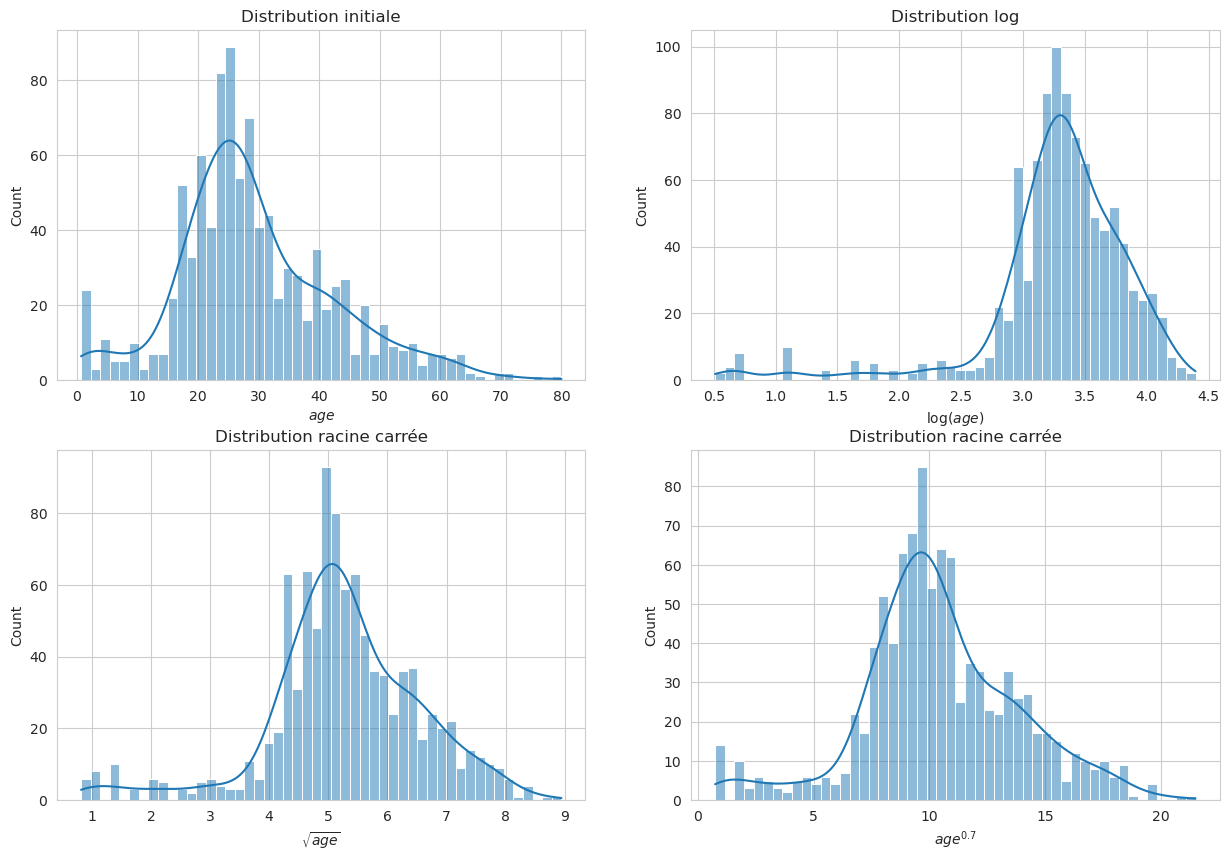

In [15]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(x=age, kde=True, bins=50, ax=ax1)
ax1.set_title("Distribution initiale")
ax1.set_xlabel("$\mathit{age}$")

sns.histplot(x=np.log(age + 1), kde=True, bins=50, ax=ax2)
ax2.set_title("Distribution log")
ax2.set_xlabel("$\log({\mathit{age}})$")

sns.histplot(x=np.sqrt(age), kde=True, bins=50, ax=ax3)
ax3.set_title("Distribution racine carrée")
ax3.set_xlabel("$\sqrt{\mathit{age}}$")

sns.histplot(x=np.power(age, 0.7), kde=True, bins=50, ax=ax4)
ax4.set_title("Distribution racine carrée")
ax4.set_xlabel("$\mathit{age}^{0.7}$");

**Observation** : la distribution $\mathit{age}^{0{,}7}$ semble la plus **équilibrée** entre gauche et droite. On le confirme numériquement en comparant les valeurs de skew des trois transformations.

In [16]:
np.log(age + 1).skew(), np.sqrt(age).skew(), np.power(age, 0.7).skew()

(np.float64(-2.1201715439764603),
 np.float64(-0.5869989275685976),
 np.float64(-0.039151129007475964))

In [17]:
def power_0_7_age_distribution(X_df):
    return np.power(X_df["age"], 0.7)

### La variable `fare`

**`fare` est connue pour être très asymétrique** (c'est ce qu'on avait vu dès le notebook `04-summarize-data` : quelques billets très chers en 1ère classe tirent la distribution). C'est un candidat idéal pour une transformation.

On calcule d'abord le skew de la distribution originale pour avoir un point de comparaison.

In [18]:
fare = impute_fare(X2_train)
fare.skew()

np.float64(4.329339554980521)

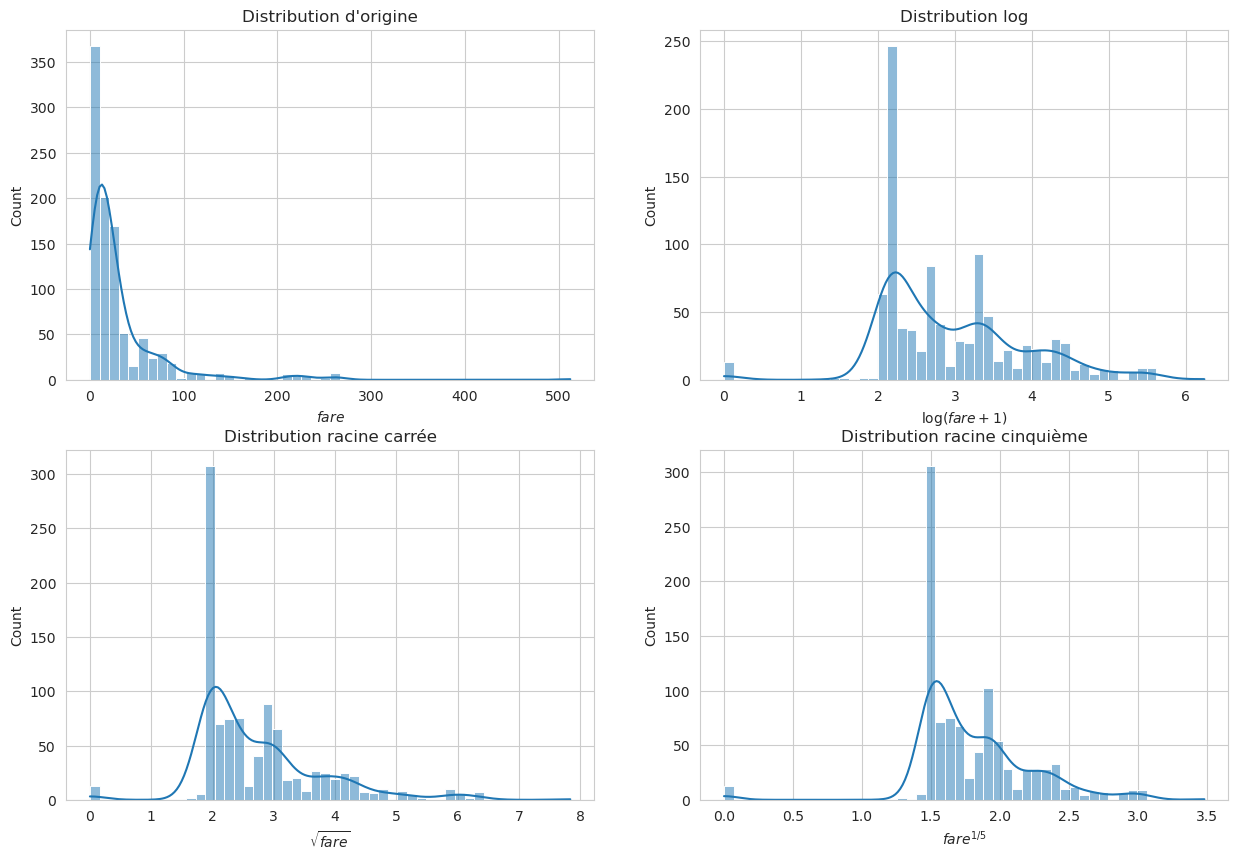

In [19]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(x=fare, kde=True, bins=50, ax=ax1)
ax1.set_title("Distribution d'origine")
ax1.set_xlabel("$\mathit{fare}$")

sns.histplot(x=np.log(fare + 1), kde=True, bins=50, ax=ax2) # log(x+1) évite les valeurs nulles
ax2.set_title("Distribution log")
ax2.set_xlabel("$\log({\mathit{fare}+1})$")

sns.histplot(x=np.power(fare, 0.33), kde=True, bins=50, ax=ax3)
ax3.set_title("Distribution racine carrée")
ax3.set_xlabel("$\sqrt{\mathit{fare}}$")

sns.histplot(x=np.power(fare, 0.2), kde=True, bins=50, ax=ax4)
ax4.set_title("Distribution racine cinquième")
ax4.set_xlabel("$\mathit{fare}^{1/5}$");


**Stratégie :** on teste plusieurs transformations, on regarde visuellement ce qui donne la distribution la plus symétrique, puis on choisit celle qui **minimise le skew**.

> **⚠️ Nuance importante :** chercher à minimiser le skew par itération est acceptable en pédagogie, mais en pratique on préfère souvent utiliser **Box-Cox** ou **Yeo-Johnson** qui trouvent **automatiquement** la meilleure puissance. Ces outils sont disponibles dans `sklearn.preprocessing.PowerTransformer`.

In [20]:
np.log(fare+1).skew(), np.sqrt(fare).skew(), np.power(fare, 0.2).skew()

(np.float64(0.48547537906712146),
 np.float64(2.021520169909295),
 np.float64(-0.028605542047637742))

In [21]:
def fifth_root_fare_distribution(X_df):
    return  np.power(X_df["fare"], 0.2)

In [22]:
def improve_distributions(X_df):
    X_df["power_0_7_age"] = power_0_7_age_distribution(X_df)
    X_df.drop("age", axis=1, inplace=True)
    X_df["fifth_root_fare"] = fifth_root_fare_distribution(X_df)
    X_df.drop("fare", axis=1, inplace=True)
    return X_df

## Fonction de prétraitement complète

**On enchaîne toutes les transformations** dans une seule fonction :
1. Suppression des colonnes inutiles
2. Imputation des NaN (stratégies conditionnelles)
3. Transformations de distribution (`age^0.7`, `fare^0.2`)
4. One-hot encoding des catégorielles

In [23]:
def process_data(X_df, mean_age, std_age, cat_cols):
    X_df = drop_columns(X_df)
    X_df = impute_null_values(X_df, mean_age, std_age)
    X_df = convert_categorical(X_df, cat_cols)
    X_df = improve_distributions(X_df)
    return X_df

## Normalisation — centrer-réduire

**Pourquoi normaliser ?** Après les transformations, les variables ont toujours des **échelles très différentes** (`pclass ∈ [1, 3]`, `sibsp ∈ [0, 8]`, `age^0.7 ∈ [0, ~15]`). Pour les modèles qui utilisent des **distances** ou des **coefficients régularisés**, cette hétérogénéité pose problème.

### Le StandardScaler de scikit-learn

Pour chaque colonne, il calcule sa moyenne $\mu$ et son écart-type $\sigma$ **sur le train**, puis transforme chaque valeur via :

$$
\Large{
z = \frac{x - \mu}{\sigma}
}
$$

**Résultat :** chaque variable a une **moyenne de 0** et un **écart-type de 1**. Toutes les variables sont désormais sur la même échelle.

> **⚠️ Très important :** le `StandardScaler` doit être **fitté uniquement sur le train** (`scaler.fit(X_train)`), puis **appliqué au test** (`scaler.transform(X_test)`). Si on fitte sur le dataset complet, on fuite de l'information du test dans le train — erreur classique.
>
> **Alternatives :**
> - **`MinMaxScaler`** : met tout entre 0 et 1 — utile quand on veut préserver la forme de la distribution originale (pas de recentrage).
> - **`RobustScaler`** : utilise médiane et IQR au lieu de moyenne et écart-type — robuste aux outliers.

In [24]:
from sklearn.preprocessing import StandardScaler

X_train = process_data(X1_train, mean_ages_class, std_ages_class, ["sex", "embarked"])
scaler = StandardScaler()
scaler.fit(X_train)
X_train.iloc[:, :] = scaler.transform(X_train)
X_train.describe()

/tmp/ipykernel_1360/2098130162.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.55520973  0.85881044 -1.55520973 -0.34819965  0.85881044  0.85881044
  0.85881044 -1.55520973  0.85881044  0.85881044 -0.34819965 -0.34819965
  0.85881044 -1.55520973 -0.34819965 -0.34819965 -1.55520973  0.85881044
  0.85881044  0.85881044  0.85881044 -0.34819965  0.85881044 -0.34819965
 -1.55520973  0.85881044 -0.34819965 -0.34819965  0.85881044 -0.34819965
 -1.55520973  0.85881044  0.85881044  0.85881044 -0.34819965 -1.55520973
  0.85881044 -1.55520973 -1.55520973 -1.55520973  0.85881044 -1.55520973
 -0.34819965 -1.55520973  0.85881044 -0.34819965 -1.55520973 -0.34819965
  0.85881044  0.85881044 -1.55520973 -1.55520973  0.85881044  0.85881044
 -0.34819965  0.85881044  0.85881044 -0.34819965 -0.34819965 -0.34819965
 -0.34819965 -1.55520973  0.85881044 -1.55520973 -0.34819965 -1.55520973
  0.85881044  0.85881044 -0.34819965 -0.34

,pclass,sibsp,parch,sex_male,embarked_Q,embarked_S,power_0_7_age,fifth_root_fare
count,9.810000e+02,9.810000e+02,9.810000e+02,9.810000e+02,9.810000e+02,9.810000e+02,9.810000e+02,9.810000e+02
mean,-3.259370e-17,5.432284e-17,-5.070132e-17,-9.415959e-17,-9.053807e-18,6.880893e-17,4.526903e-17,-2.951541e-16
std,1.000510e+00,1.000510e+00,1.000510e+00,1.000510e+00,1.000510e+00,1.000510e+00,1.000510e+00,1.000510e+00
min,-1.555210e+00,-4.680829e-01,-4.404351e-01,-1.348690e+00,-3.331445e-01,-1.551209e+00,-2.836003e+00,-4.250874e+00
25%,-3.481996e-01,-4.680829e-01,-4.404351e-01,-1.348690e+00,-3.331445e-01,-1.551209e+00,-5.487730e-01,-6.970509e-01
50%,8.588104e-01,-4.680829e-01,-4.404351e-01,7.414601e-01,-3.331445e-01,6.446584e-01,-1.084998e-01,-2.402182e-01
75%,8.588104e-01,4.558393e-01,-4.404351e-01,7.414601e-01,-3.331445e-01,6.446584e-01,5.842602e-01,4.117712e-01
max,8.588104e-01,6.923294e+00,1.063820e+01,7.414601e-01,3.001700e+00,6.446584e-01,3.249814e+00,3.936156e+00


## Apprentissage

**Le moment de vérité** : est-ce que toutes ces transformations apportent un gain mesurable ? On entraîne une régression logistique et on compare les scores en cross-validation à ceux du notebook précédent.

In [25]:
logreg_clf = LogisticRegression(C=0.8, max_iter=1000)

In [26]:
scores = cross_val_score(logreg_clf, X_train, y_train, cv=10)
scores, scores.mean(), scores.std()

(array([0.82828283, 0.78571429, 0.85714286, 0.76530612, 0.73469388,
        0.82653061, 0.78571429, 0.84693878, 0.80612245, 0.82653061]),
 np.float64(0.8062976705833849),
 np.float64(0.03632329250576324))

### Autres modèles

On teste aussi un **Random Forest** — mais avec une attente différente.

> **⚠️ Rappel important :** les modèles à base d'arbres (Random Forest, XGBoost) sont **quasiment insensibles** aux transformations de distribution et à la normalisation. Ils découpent par seuils, et un seuil reste un seuil que la variable soit en échelle linéaire, en log ou en puissance.
>
> **Conséquence :** ne t'attends pas à un gain avec Random Forest. Si tu vois une amélioration, elle est probablement due au hasard (bruit de cross-validation).

In [27]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(max_depth=6, random_state=2, n_jobs=-1)
scores = cross_val_score(rf_clf, X_train, y_train, cv=10)
scores, scores.mean(), scores.std()

(array([0.84848485, 0.81632653, 0.87755102, 0.75510204, 0.76530612,
        0.85714286, 0.83673469, 0.80612245, 0.81632653, 0.78571429]),
 np.float64(0.8164811379097093),
 np.float64(0.037759204419444234))

## Conclusion

**Résultat observé :** pas d'amélioration notable pour les deux modèles.

> **🎯 Ça ne marche pas à tous les coups — et c'est normal.** Le feature engineering, c'est un processus **expérimental** : on forme des hypothèses, on les teste, on mesure, on garde ce qui marche et on jette le reste. Une expérience qui échoue n'est **pas** un échec — c'est une information.
>
> **Pourquoi ça n'a pas marché ici ?** Plusieurs raisons possibles :
> - Le dataset Titanic est **petit** (~1300 lignes) : la variance du score en cross-validation peut noyer tout gain réel.
> - Les **deux modèles** testés sont en grande partie **insensibles** aux transformations : la régression logistique avec `C=0.8` a peu de régularisation, et le Random Forest ne se soucie pas de la forme.
> - Les transformations ont été appliquées **sans tuning systématique** — peut-être qu'un `PowerTransformer` avec ajustement automatique donnerait mieux.
>
> **Leçon pour la pratique :** toujours **mesurer** l'impact d'une transformation avant de la garder dans ton pipeline. La complexité ajoutée doit être justifiée par un gain mesurable — sinon, c'est du code en plus qui peut cacher des bugs, sans bénéfice.

## 🎯 Pour résumer — transformations de distribution

### Quand investir dans ces techniques

**Candidats pertinents** (où ça peut payer) :
- ✅ Variables avec **skew fort** (>1 en valeur absolue) et **distribution clairement asymétrique**.
- ✅ **Régression linéaire** ou **logistique** comme modèle principal.
- ✅ Algorithmes basés sur **distances** (KNN, K-Means, SVM).
- ✅ **Réseaux de neurones** (convergence plus rapide avec entrées standardisées).

**Candidats moins utiles** (où le gain est souvent nul) :
- ❌ **Random Forest, XGBoost, LightGBM** — ils sont insensibles à la forme des distributions.
- ❌ Variables déjà à peu près symétriques.
- ❌ Datasets très grands où le modèle peut apprendre les non-linéarités tout seul.

### Les outils scikit-learn à connaître

| Outil | Usage |
|---|---|
| **`StandardScaler`** | Centrer-réduire : moyenne 0, écart-type 1 |
| **`MinMaxScaler`** | Mettre entre 0 et 1 (préserve la forme) |
| **`RobustScaler`** | Centrer-réduire avec médiane et IQR (robuste aux outliers) |
| **`PowerTransformer`** (Box-Cox / Yeo-Johnson) | Recherche automatique de la transformation optimale |
| **`QuantileTransformer`** | Transforme en gaussienne ou uniforme par rangs (très robuste) |
| **`FunctionTransformer`** | Pour intégrer une fonction custom (log, sqrt...) dans un pipeline |

### Les bonnes pratiques

- ✅ **Mesurer avant/après** : toujours vérifier que la transformation apporte un gain. Sinon, garder la version simple.
- ✅ **Automatiser avec `PowerTransformer`** plutôt que de choisir une puissance à la main — moins de biais, meilleur tuning.
- ✅ **Fitter sur le train uniquement**, appliquer au test. Utiliser un **`Pipeline`** pour éviter les fuites automatiquement.
- ✅ **Tester la cohérence métier** : une transformation log sur un revenu est très courante ; une transformation log sur un âge est plus bizarre — se demander si ça a du sens.
- ✅ **Comparer plusieurs transformations** (log, sqrt, puissance, Box-Cox, QuantileTransformer) et choisir celle qui donne le meilleur skew **ET** le meilleur score en CV.

### Les pièges à éviter

- ⚠️ **Appliquer log sur des valeurs négatives ou nulles** → NaN/Inf. Utiliser `np.log1p(x) = log(1+x)` ou `PowerTransformer` (Yeo-Johnson) pour gérer ce cas.
- ⚠️ **Transformer la cible sans l'inverser** pour interpréter les prédictions (typique en régression : `log(price)`).
- ⚠️ **Normaliser avant d'imputer** → les imputations sont faussées. Faire d'abord l'imputation, puis la normalisation.
- ⚠️ **Tout normaliser par réflexe** → inutile pour les arbres, et peut compliquer l'interprétation.
- ⚠️ **Surestimer le gain** : un gain de 0,2% en cross-validation sur un dataset de 1000 lignes est probablement du bruit.

### Le mot de la fin

> **Une bonne distribution n'est pas une fin en soi, c'est un moyen.** L'objectif reste la **performance du modèle en production**, pas la beauté des histogrammes. Si transformer tes variables apporte un gain mesurable et stable en cross-validation, garde-le. Sinon, abandonne — la simplicité est ton amie. Le feature engineering est un art de l'**expérimentation éclairée**, pas de la théorie pure.